In [1]:
import jax 
jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
import atmo3 as a3 
import cmocean as cmo
import os

In [2]:
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation
import astropy.units as u

## Grid parameters

In [3]:
nside_grid = 128
box_length_in_m = 10000.0
site_altitude = 5110.0  # Atacama altitude in meters
injection_scale_in_m = 200.0  # Injection scale in meters
UTC_hour = 20 # Example UTC hour for the Atacama site
P_surface = 58800.  # Surface pressure in Pa or kg/(m.s^2)

print(f"Initializing atmosphere with nside_grid={nside_grid} and box_length_in_m={box_length_in_m} and site_altitude={site_altitude} meters")
atmo = a3.Atmosphere(
        nside_grid=nside_grid, 
        box_length_in_m=box_length_in_m,
        site_altitude=site_altitude,  # Atacama altitude in meters
        )

Initializing atmosphere with nside_grid=128 and box_length_in_m=10000.0 and site_altitude=5110.0 meters


Creating power spectrum for specific humidity normalized to 1.

In [4]:
k_array     = np.arange(nside_grid) * atmo.grid_wsp.dk
# Based on the Kolmogorov spectrum, we can define a power spectrum based on values from Morris et al. (2025) (arxiv:2410.13064)
k0          = 2*np.pi / injection_scale_in_m
pofk_array  = ( k0**2. + k_array**2 )**-(11/6)
pofk_array /= np.max(pofk_array)  # Normalize the power spectrum to 1
pspec = {'k': k_array, 'pofk': pofk_array}

Creating rescaling factors for the grid...

In [5]:
mean_q_profile  = np.load('./mean_q_profiles_2023_07.npz')['typical_profiles']   # kg/kg
delta_q_profile = np.load('./delta_q_profiles_2023_07.npz')['delta_q_map'] # kg/kg
mean_ta_profile = np.load('./mean_ta_profiles_2023_07.npz')['typical_profiles']   # K
altitude        = np.load('./delta_q_profiles_2023_07.npz')['alt_grid']    # m

rescale_delta_q = {'h': altitude, 'f': delta_q_profile[UTC_hour]}
rescale_mean_q  = {'h': altitude, 'f': mean_q_profile[UTC_hour]}
rescale_mean_t  = {'h': altitude, 'f': mean_ta_profile[UTC_hour]}

Adding component: specific humidity with unit kg/kg

In [6]:
atmo.add_component(
    field_name='specific humidity',
    field_unit='kg/kg',
    pspec=pspec,
    rescale=rescale_delta_q,
    mean=rescale_mean_q,
    seed=123456789,
)

atmo.add_property(
    property_name='temperature',
    property_unit='K',
    property_value=rescale_mean_t
)

Generating realization for the component...

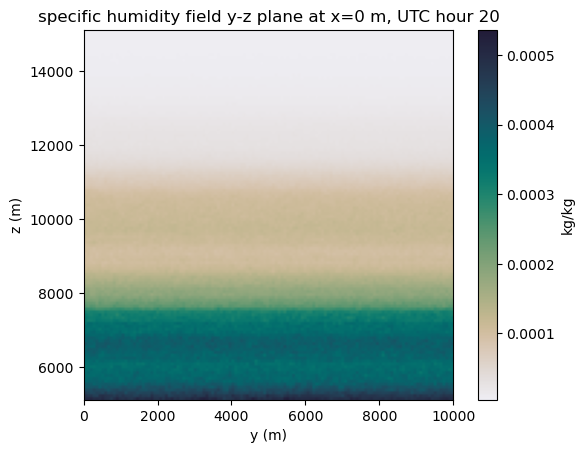

In [7]:
atmo.generate_realization(time_step=0)

plt.imshow(
    atmo.components['specific humidity'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.rain, origin='lower', vmin=atmo.components['specific humidity'].field.min(), vmax=atmo.components['specific humidity'].field.max()
)
plt.colorbar(label='kg/kg')
plt.title(f"specific humidity field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()


Computing dependent fields: virtual temperature, pressure, water vapor density, and precipitable water vapor...

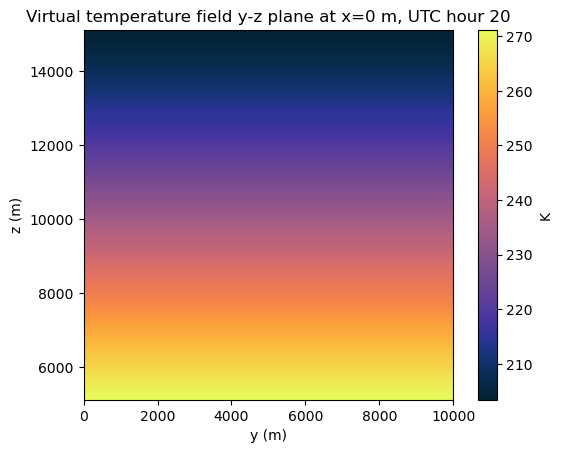

In [8]:
atmo.compute_virtual_temperature()

plt.imshow(
    atmo.components['virtual temperature'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.thermal, origin='lower', vmin=atmo.components['virtual temperature'].field.min(), vmax=atmo.components['virtual temperature'].field.max()
)
plt.colorbar(label='K')
plt.title(f"Virtual temperature field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

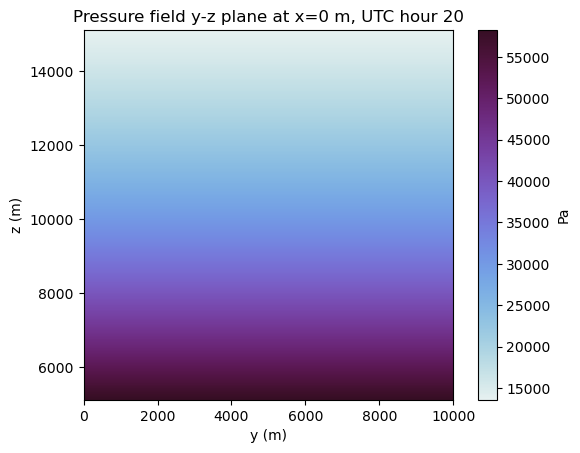

In [9]:
atmo.compute_pressure(P_surface=P_surface)  # Surface pressure in Pa

plt.imshow(
    atmo.components['pressure'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.dense, origin='lower', vmin=atmo.components['pressure'].field.min(), vmax=atmo.components['pressure'].field.max()
)
plt.colorbar(label='Pa')
plt.title(f"Pressure field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

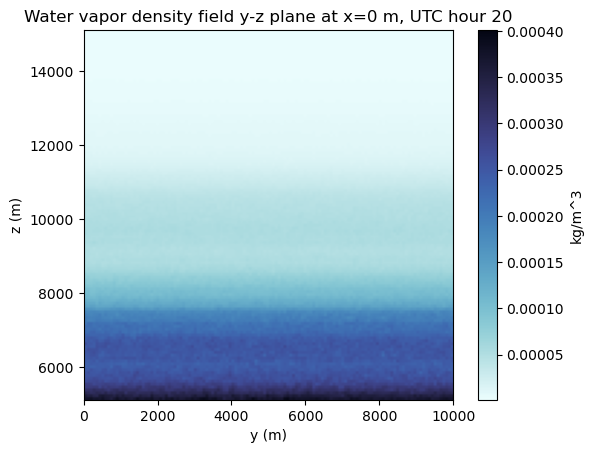

In [10]:
atmo.compute_water_vapor_density()
plt.imshow(
    atmo.components['water vapor density'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.ice_r, origin='lower', vmin=atmo.components['water vapor density'].field.min(), vmax=atmo.components['water vapor density'].field.max()
)
plt.colorbar(label='kg/m^3')
plt.title(f"Water vapor density field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

In [11]:
pwv_cube = atmo.components['water vapor density'].field

In [12]:
type(atmo.components['water vapor density'])

atmo3.cube.Cube

In [13]:
pwv_cube.shape

(128, 128, 128)

## Compute LOS coprdinates for each altitde slice

Define instrument static position and pointing

In [14]:
theta = 50.0  # degrees
phi = 30.0  # degrees
fwhm = 5.  # degrees
detector_position = jnp.array(
    [0, 0, 0]
)
unit_pointing_vec_reference = atmo.grid_wsp.lonlat_to_unitvec(theta, phi, lonlat=True)

In [15]:
import healpy as hp
lmax = 3000

beam_window = hp.sphtfunc.gauss_beam(fwhm=jnp.radians(fwhm), lmax=lmax)

theta_range = jnp.linspace(0, jnp.radians(2*jnp.pi), 100)
beam_profile = hp.sphtfunc.bl2beam(beam_window,theta=theta_range)

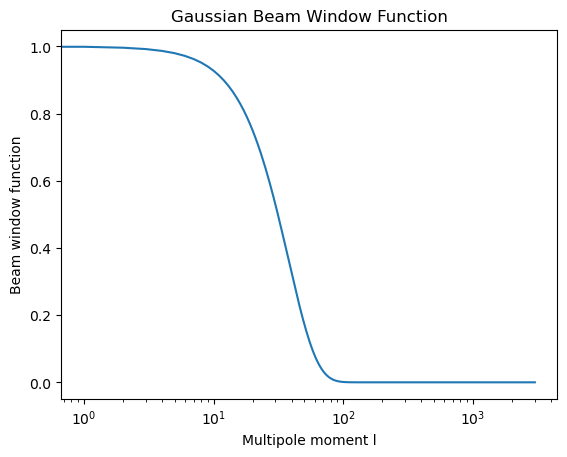

In [16]:
plt.plot(beam_window)
plt.xlabel('Multipole moment l')
plt.ylabel('Beam window function')
plt.title('Gaussian Beam Window Function')
plt.xscale('log')
plt.show()

Text(0.5, 1.0, 'Gaussian Beam Profile')

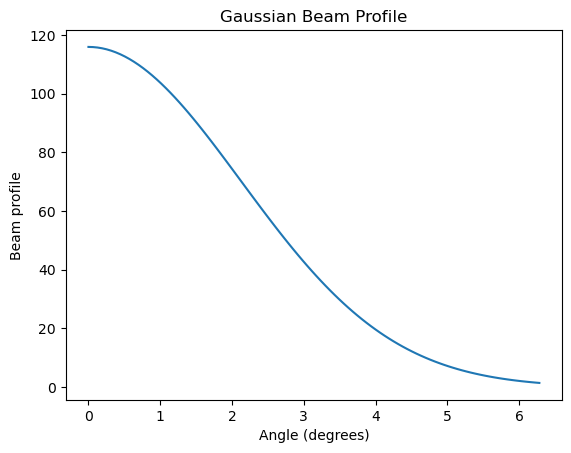

In [17]:
plt.plot(jnp.degrees(theta_range), beam_profile)
plt.xlabel('Angle (degrees)')
plt.ylabel('Beam profile')
plt.title('Gaussian Beam Profile')

In [108]:
b_hwhm = hp.sphtfunc.bl2beam(beam_window,theta=jnp.radians(jnp.array([fwhm])/2))
b_center = hp.sphtfunc.bl2beam(beam_window,theta=jnp.array([0.0]))
print(f"Beam profile at FWHM angle/2: {b_hwhm}, Beam profile at center: {b_center}")

Beam profile at FWHM angle/2: [57.96677766], Beam profile at center: [115.91516134]


Define total rotation

In [ ]:
def rotation_matrix(elevation_in_deg, azimuth_in_deg):
    rot_y = Rotation.from_euler('y', -elevation_in_deg, degrees=True)
    rot_z = Rotation.from_euler('z', azimuth_in_deg, degrees=True)
    total_rotation = rot_z * rot_y
    return total_rotation

In [19]:
def polygonal_vertices(polygon_order, fwhm: u.Quantity):
    angles = jnp.linspace(0, 2 * jnp.pi, polygon_order, endpoint=False)
    if fwhm.unit.is_equivalent(u.degree):
        fwhm = fwhm.to(u.radian)
    cos = jnp.cos(fwhm.to(u.radian).value)
    sin = jnp.sin(fwhm.to(u.radian).value)
    return jnp.array([cos*jnp.ones_like(angles),
                      sin*jnp.cos(angles),
                      sin*jnp.sin(angles)]).T

In [20]:
def hexagon_second_rim(fwhm: u.Quantity):
    vertices = polygonal_vertices(6, 2*fwhm)
    ## add midpoints between two consecutive vertices
    midpoints = (vertices + jnp.roll(vertices, -1, axis=0)) / 2
    return jnp.vstack([vertices, midpoints])


In [21]:
rotation_matrix_total = rotation_matrix(elevation_in_deg=theta, azimuth_in_deg=phi)

In [22]:
hexagonal_fp_first_rim = polygonal_vertices(polygon_order=6, fwhm=fwhm*u.deg/2)
hexagonal_fp_second_rim = hexagon_second_rim(fwhm*u.deg/2)

rotated_fp_first_rim = rotation_matrix_total.apply(hexagonal_fp_first_rim)
rotated_fp_second_rim = rotation_matrix_total.apply(hexagonal_fp_second_rim)

## Plotting utils

In [23]:
import plotly.graph_objects as go

In [24]:
def add_axis(fig, start, direction, length, color="black", width=8, arrow_frac=0.1):
    """
    Add a 3D axis line to a Plotly figure.

    Parameters
    ----------
    fig : go.Figure
        The Plotly 3D figure.
    start : tuple of 3 floats
        (x, y, z) starting point of the axis.
    direction : str
        Axis direction: 'x', 'y', or 'z'.
    length : float
        Length of the axis line.
    color : str, optional
        Line color. Default is 'black'.
    width : float, optional
        Line width. Default is 8.
    arrow_frac : float, optional
        Fraction of the line to allocate for arrowhead.
    """
    x_det, y_det, z_det = start

    if direction == "x":
        x = [x_det, x_det + length]
        y = [y_det, y_det]
        z = [z_det, z_det]
        unit_vec = jnp.array([1, 0, 0])
    elif direction == "y":
        x = [x_det, x_det]
        y = [y_det, y_det + length]
        z = [z_det, z_det]
        unit_vec = jnp.array([0, 1, 0])
    elif direction == "z":
        x = [x_det, x_det]
        y = [y_det, y_det]
        z = [z_det, z_det + length]
        unit_vec = jnp.array([0, 0, 1])
    else:
        raise ValueError(f"Unknown direction: {direction}")

    norm_vec = unit_vec / jnp.linalg.norm(unit_vec) * length

    tip = jnp.array([x_det, y_det, z_det]) + norm_vec

    fig.add_trace(
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="lines",
            line=dict(color=color, width=width),
            showlegend=False,
        )
    )

    # Arrowhead: small lines forming a "V"
    arrow_len = length * arrow_frac
    # Pick two perpendicular vectors to direction
    if jnp.allclose(norm_vec[:2], 0):
        perp1 = jnp.array([1, 0, 0])
    else:
        perp1 = jnp.array([-norm_vec[1], norm_vec[0], 0])
    perp1 = perp1 / jnp.linalg.norm(perp1) * arrow_len

    perp2 = jnp.cross(norm_vec, perp1)
    perp2 = perp2 / jnp.linalg.norm(perp2) * arrow_len

    for vec in [perp1, -perp1, perp2, -perp2]:
        fig.add_trace(
            go.Scatter3d(
                x=[tip[0], tip[0] - vec[0]],
                y=[tip[1], tip[1] - vec[1]],
                z=[tip[2], tip[2] - vec[2]],
                mode="lines",
                line=dict(color=color, width=width),
                showlegend=False,
            )
        )

In [25]:
def add_cone_mesh(
    fig,
    det_pos,
    unit_pointing_vec_reference,
    gamma_tol,
    cone_length=500.0,
    n_circle=16,
    n_length=10,
    color="blue",
    opacity=0.12,
    name="Cone",
):
    """
    Add a triangular mesh representing a cone (field-of-view) to a Plotly Figure.

    Parameters
    ----------
    fig : plotly.graph_objects.Figure
        Figure to draw the mesh into (modified in-place).
    det_pos : array-like (3,)
        Detector position in the same coordinate system as the cone (i,j,k or meters).
    unit_pointing_vec_reference : array-like (3,)
        Unit vector for pointing direction.
    gamma_tol : float
        Cone half-angle in degrees.
    cone_length : float, optional
        Length of the cone (default: 500.0).
    n_circle : int, optional
        Number of points around each circular layer (default: 16).
    n_length : int, optional
        Number of layers along the cone length (default: 10).
    color : str, optional
        Mesh color.
    opacity : float, optional
        Mesh opacity.
    name : str, optional
        Legend name for the mesh.

    Returns
    -------
    verts : ndarray
        Array of vertices shape (n_circle*n_length, 3)
    faces : ndarray
        Array of triangle faces shape (n_triangles, 3)
    """
    det_pos = jnp.asarray(det_pos)
    u = jnp.asarray(unit_pointing_vec_reference)

    # choose a reference vector not parallel to u
    ref = jnp.array([0, 0, 1])
    if jnp.isclose(jnp.abs(jnp.dot(u, ref)), 1.0):
        ref = jnp.array([0, 1, 0])

    e1 = jnp.cross(u, ref)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(u, e1)

    t_vals = jnp.linspace(0, cone_length, n_length)
    phi_vals = jnp.linspace(0, 2 * jnp.pi, n_circle, endpoint=False)

    vertices = []
    for t in t_vals:
        R = t * jnp.tan(jnp.deg2rad(gamma_tol))
        for phi in phi_vals:
            point = det_pos + u * t + R * (jnp.cos(phi) * e1 + jnp.sin(phi) * e2)
            vertices.append(point)

    vertices = jnp.asarray(vertices)
    x, y, z = vertices.T

    # build faces connecting layer i to i+1
    faces = []
    for i in range(n_length - 1):
        for j in range(n_circle):
            j_next = (j + 1) % n_circle
            a = i * n_circle + j
            b = i * n_circle + j_next
            c = (i + 1) * n_circle + j
            d = (i + 1) * n_circle + j_next
            faces.append([a, b, c])
            faces.append([b, d, c])
    faces = jnp.asarray(faces)

    # Add mesh to figure
    fig.add_trace(
        go.Mesh3d(
            x=x,
            y=y,
            z=z,
            i=faces[:, 0].astype(int),
            j=faces[:, 1].astype(int),
            k=faces[:, 2].astype(int),
            color=color,
            opacity=opacity,
            name=name,
            hoverinfo="skip",
            showscale=False,
        )
    )

    return vertices, faces

In [26]:
cone_length = 1.01 * atmo.grid_wsp.N
n_circle = 16  # number of points around circle
n_length = 10  # number of layers along the cone

# Build local orthonormal frame for cone base
ref = jnp.array([0, 0, 1])
detector_position_ijk = detector_position / atmo.grid_wsp.grid_spacing
det_pos_i, det_pos_j, det_pos_k = detector_position_ijk

## Implement interpolation

In [27]:
z_slice_grid = atmo.grid_wsp.grid_axis(altitude_axis=True)

In [28]:
z_slice_grid

Array([ 5110.   ,  5188.125,  5266.25 ,  5344.375,  5422.5  ,  5500.625,
        5578.75 ,  5656.875,  5735.   ,  5813.125,  5891.25 ,  5969.375,
        6047.5  ,  6125.625,  6203.75 ,  6281.875,  6360.   ,  6438.125,
        6516.25 ,  6594.375,  6672.5  ,  6750.625,  6828.75 ,  6906.875,
        6985.   ,  7063.125,  7141.25 ,  7219.375,  7297.5  ,  7375.625,
        7453.75 ,  7531.875,  7610.   ,  7688.125,  7766.25 ,  7844.375,
        7922.5  ,  8000.625,  8078.75 ,  8156.875,  8235.   ,  8313.125,
        8391.25 ,  8469.375,  8547.5  ,  8625.625,  8703.75 ,  8781.875,
        8860.   ,  8938.125,  9016.25 ,  9094.375,  9172.5  ,  9250.625,
        9328.75 ,  9406.875,  9485.   ,  9563.125,  9641.25 ,  9719.375,
        9797.5  ,  9875.625,  9953.75 , 10031.875, 10110.   , 10188.125,
       10266.25 , 10344.375, 10422.5  , 10500.625, 10578.75 , 10656.875,
       10735.   , 10813.125, 10891.25 , 10969.375, 11047.5  , 11125.625,
       11203.75 , 11281.875, 11360.   , 11438.125, 

In [29]:
def los_points_coords_radius(altitude_slice,unit_vector,det_pos):
    r = (altitude_slice - site_altitude) / unit_vector[2]
    x_los = det_pos[0] + r * unit_vector[0]
    y_los = det_pos[1] + r * unit_vector[1]
    return jnp.array([x_los, y_los, altitude_slice, r]).T

In [30]:
los_ref = los_points_coords_radius(z_slice_grid, unit_pointing_vec_reference, detector_position)

In [31]:
los_ref[1].shape

(4,)

In [32]:
rotated_fp_first_rim.shape

(6, 3)

In [33]:
# Create interactive 3D plot with Plotly
fig = go.Figure()

N = nside_grid


fig.add_trace(
    go.Scatter3d(
        x=los_ref[:,0]/atmo.grid_wsp.grid_spacing,
        y=los_ref[:,1]/atmo.grid_wsp.grid_spacing,
        z=(los_ref[:,2]-site_altitude)/atmo.grid_wsp.grid_spacing,
        mode="markers",
        marker=dict(size=1, color="black", opacity=0.5),
        name="Line of sight points",
        showlegend=True,
    )
)

for ivertex, vertex in enumerate(rotated_fp_first_rim):
    los_vertex = los_points_coords_radius(z_slice_grid, vertex, detector_position)
    fig.add_trace(
        go.Scatter3d(
            x=los_vertex[:,0] / atmo.grid_wsp.grid_spacing,
            y=los_vertex[:,1] / atmo.grid_wsp.grid_spacing,
            z=(los_vertex[:,2]-site_altitude) / atmo.grid_wsp.grid_spacing,
            mode="markers",
            marker=dict(size=1, color="green", symbol="circle",opacity=0.7),
            name="Focalplane first rim",
            showlegend=True if ivertex == 0 else False,
        )
    )

for ivertex, vertex in enumerate(rotated_fp_second_rim):
    los_vertex = los_points_coords_radius(z_slice_grid, vertex, detector_position)
    fig.add_trace(
        go.Scatter3d(
            x=los_vertex[:,0] / atmo.grid_wsp.grid_spacing,
            y=los_vertex[:,1] / atmo.grid_wsp.grid_spacing,
            z=(los_vertex[:,2]-site_altitude) / atmo.grid_wsp.grid_spacing,
            mode="markers",
            marker=dict(size=1, color="blue", symbol="circle",opacity=0.4),
            name="Focalplane second rim",
            showlegend=True if ivertex == 0 else False,
        )
    )

# Add detector position
fig.add_trace(
    go.Scatter3d(
        x=[det_pos_i],
        y=[det_pos_j],
        z=[det_pos_k],
        mode="markers",
        marker=dict(size=6, color="red", symbol="diamond"),
        name="Detector",
        showlegend=True,
    )
)

# Add detector coordinate axes
axis_len = N // 10.0


add_axis(fig, (det_pos_i, det_pos_j, det_pos_k), "x", axis_len, color="black")
add_axis(fig, (det_pos_i, det_pos_j, det_pos_k), "y", axis_len, color="black")
add_axis(fig, (det_pos_i, det_pos_j, det_pos_k), "z", axis_len, color="black")

add_cone_mesh(
    fig,
    det_pos=(det_pos_i, det_pos_j, det_pos_k),
    unit_pointing_vec_reference=unit_pointing_vec_reference,
    gamma_tol=fwhm,
    cone_length=cone_length,
    n_circle=n_circle,
    n_length=n_length,
    color="orange",
    opacity=0.3,
    name=r"Cone of separation angle $\gamma = $" + str(fwhm) + "°",
)

fig.update_layout(
    scene=dict(
        xaxis=dict(
            title="X (m)",
            tickmode="array",
            tickvals=list(range(0, N, N // 5)),  # voxel indices
            ticktext=[
                f"{val * atmo.grid_wsp.grid_spacing:.0f}" for val in range(0, N, N // 5)
            ],  # physical coords
        ),
        yaxis=dict(
            title="Y (m)",
            tickmode="array",
            tickvals=list(range(0, N + 1, N // 5)),
            ticktext=[
                f"{val * atmo.grid_wsp.grid_spacing:.0f}" for val in range(0, N, N // 5)
            ],
        ),
        zaxis=dict(
            title="Z (m)",
            tickmode="array",
            tickvals=list(range(0, N + 1, N // 5)),
            ticktext=[
                f"{val * atmo.grid_wsp.grid_spacing:.0f}" for val in range(0, N, N // 5)
            ],
        ),
        aspectmode="cube",
    ),
    title="Interactive 3D Visualization: Detector + Voxel Grid + Line-of-Sight Points in a given layer",
    width=900,
    height=700,
    margin=dict(r=20, b=10, l=10, t=40),
)

# Show the plot
fig.show()

### Let's interpolate the cube

In [34]:
from jax.scipy.interpolate import RegularGridInterpolator

In [ ]:
x = atmo.grid_wsp.grid_axis()
y = atmo.grid_wsp.grid_axis(slab_axis=True)
z = atmo.grid_wsp.grid_axis(altitude_axis=True)
xx, yy, zz = jnp.meshgrid(x, y, z, indexing="ij")
xyz_meshgrid = jnp.stack([xx, yy, zz], axis=0)

In [37]:
xyz_meshgrid.shape

(3, 128, 128, 128)

In [38]:
xyz_meshgrid[1]

Array([[[   0.   ,    0.   ,    0.   , ...,    0.   ,    0.   ,
            0.   ],
        [  78.125,   78.125,   78.125, ...,   78.125,   78.125,
           78.125],
        [ 156.25 ,  156.25 ,  156.25 , ...,  156.25 ,  156.25 ,
          156.25 ],
        ...,
        [9765.625, 9765.625, 9765.625, ..., 9765.625, 9765.625,
         9765.625],
        [9843.75 , 9843.75 , 9843.75 , ..., 9843.75 , 9843.75 ,
         9843.75 ],
        [9921.875, 9921.875, 9921.875, ..., 9921.875, 9921.875,
         9921.875]],

       [[   0.   ,    0.   ,    0.   , ...,    0.   ,    0.   ,
            0.   ],
        [  78.125,   78.125,   78.125, ...,   78.125,   78.125,
           78.125],
        [ 156.25 ,  156.25 ,  156.25 , ...,  156.25 ,  156.25 ,
          156.25 ],
        ...,
        [9765.625, 9765.625, 9765.625, ..., 9765.625, 9765.625,
         9765.625],
        [9843.75 , 9843.75 , 9843.75 , ..., 9843.75 , 9843.75 ,
         9843.75 ],
        [9921.875, 9921.875, 9921.875, ..., 9921

In [39]:
pwv_cube.ndim

3

In [40]:
len(xyz_meshgrid)

3

In [41]:
type(pwv_cube)

jaxlib.xla_extension.ArrayImpl

In [42]:
interpolator = RegularGridInterpolator((x,y,z), pwv_cube, method='linear')

In [43]:
len(interpolator.grid)

3

In [44]:
los_ref.shape

(128, 4)

Concatenate center pixel and first rim

In [90]:
los_first_rim = jnp.array([los_points_coords_radius(z_slice_grid, vertex, detector_position) for vertex in rotated_fp_first_rim])

In [91]:
los_first_rim.shape

(6, 128, 4)

In [92]:
los_center_and_first_rim = jnp.concatenate([los_ref[None, :, :], los_first_rim], axis=0)

In [93]:
los_center_and_first_rim.shape

(7, 128, 4)

In [61]:
mask_los_rad = los_center_and_first_rim[..., 3] <= atmo.grid_wsp.Lbox

In [62]:
mask_los_rad.shape

(7, 128)

In [76]:
jnp.where(~mask_los_rad[-1])

(Array([ 95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
        108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
        121, 122, 123, 124, 125, 126, 127], dtype=int64),)

In [63]:
masked_los_center_and_first_rim = los_center_and_first_rim*mask_los_rad[..., None]

In [77]:
masked_los_center_and_first_rim_nan = jnp.where(mask_los_rad[..., None], los_center_and_first_rim, jnp.nan) 

In [78]:
interpolated_values_total = interpolator(masked_los_center_and_first_rim_nan[..., :3])

In [94]:
interpolated_values_total = interpolator(los_center_and_first_rim[..., :3])

In [84]:
interpolated_values_total.shape

(7, 128)

In [85]:
masked_los_center_and_first_rim

Array([[[   0.        ,    0.        , 5110.        ,    0.        ],
        [  56.77199976,   32.77732934, 5188.125     ,  101.98494448],
        [ 113.54399952,   65.55465869, 5266.25      ,  203.96988896],
        ...,
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ]],

       [[   0.        ,    0.        , 5110.        ,    0.        ],
        [  54.54562034,   36.63353161, 5188.125     ,  102.08210402],
        [ 109.09124068,   73.26706323, 5266.25      ,  204.16420805],
        ...,
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ]],

       [[   0.        ,    0.        , 5110.        ,    0.        ],
        [  51.46760781,   32.20658166, 5188.125     ,   98.9

In [99]:
integrated_pwv_total = jnp.trapezoid(interpolated_values_total, masked_los_center_and_first_rim[..., 3], axis=1)

In [100]:
# interpolated_values_los_ref = interpolator(los_ref[1].T)
# integrated_pwv_center =  jnp.trapezoid(interpolated_values_los_ref, los_ref[0])
# integrated_pwv_first_rim = []
# for vertex in rotated_fp_first_rim:
#     los_vertex = los_points(z_slice_grid, vertex, detector_position)
#     interpolated_values = interpolator(los_vertex[1].T)
#     integrated_pwv = jnp.trapezoid(interpolated_values, los_vertex[0])
#     integrated_pwv_first_rim.append(integrated_pwv) 

Array(1.11263289, dtype=float64)
[Array(1.1121287, dtype=float64),
Array(1.07748966, dtype=float64),
Array(1.07318654, dtype=float64),
Array(1.11026428, dtype=float64),
Array(1.14998911, dtype=float64),
Array(1.14938246, dtype=float64)]

In [101]:
# integrated_pwv_center
# integrated_pwv_first_rim

In [102]:
integrated_pwv_total

Array([1.04758374, 1.04091421, 1.02592373, 1.02071053, 1.03754124,
       1.06244828, 1.05957061], dtype=float64)

In [104]:
jnp.mean(integrated_pwv_total, axis=0)

Array(1.04209891, dtype=float64)